In [1]:
import torch

torch.cuda.is_available()


True

In [1]:
import pandas as pd

# 기본 테이블
df = pd.read_csv("data/master_dataset_with_roles_final.csv")
df.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department,role_train,role_test
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs,prior,ign
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce,prior,ign
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry,prior,ign
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13,oils vinegars,pantry,prior,ign
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13,baking ingredients,pantry,prior,ign


In [6]:
print(df['eval_set'].value_counts(dropna=False))

eval_set
prior    20641991
test     11792498
train     1384617
Name: count, dtype: int64


In [21]:
import pandas as pd
from collections import defaultdict

# 1. 데이터 불러오기
# df = pd.read_csv("../data/master_dataset_with_roles_final.csv")

# 2. test 유저 추출
test_users = df[df["eval_set"] == "test"]["user_id"].unique()

# test 유저의 prior 주문만 추출 (즉, test 주문 제외한 모든 주문)
test_df = df[(df["user_id"].isin(test_users)) & (df["eval_set"] != 'test')]

test_df

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department,role_train,role_test


✅ 통계 비교 (test 유저 prior 기준)
- 전체 test 유저 수            : 75,000
- 통합 전 시퀀스 생성 유저 수   : 0
- 통합 후 시퀀스 유지 유저 수   : 0
- 제거된 유저 수               : 0
- 평균 시퀀스 길이 (전/후)      : nan → nan


/home/owner/anaconda3/envs/bert4ether/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/owner/anaconda3/envs/bert4ether/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/owner/anaconda3/envs/bert4ether/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/owner/anaconda3/envs/bert4ether/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51200 (\N{HANGUL SYLLABLE JEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/owner/anaconda3/envs/bert4ether/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu

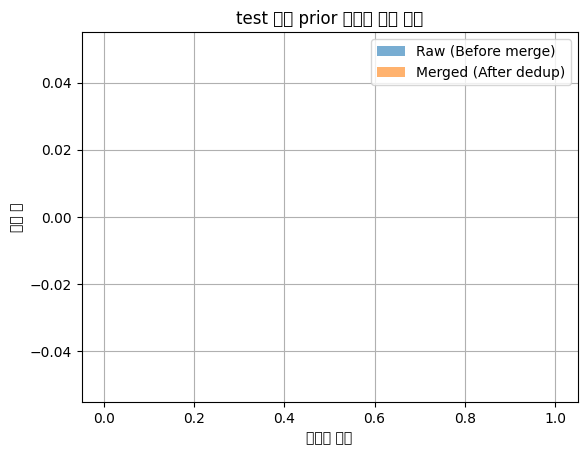

In [16]:
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터 로드
# df = pd.read_csv("../data/master_dataset_with_roles_final.csv")

# 2. test 유저 추출
test_users = df[df["eval_set"] == "test"]["user_id"].unique()

# 3. test 유저의 prior 주문만 추출
prior_df = df[(df["user_id"].isin(test_users)) & (df["eval_set"] == "prior")]

# 4. 시퀀스 생성 (통합 전)
def seq_from_df(df):
    user2seq = defaultdict(list)
    df = df.sort_values(by=["user_id", "order_number", "add_to_cart_order"])
    for row in df.itertuples():
        user2seq[row.user_id].append({
            "product_id": row.product_id,
            "reordered": row.reordered,
            "hour": row.order_hour_of_day,
            "aisle": row.aisle_id,
            "department": row.department_id,
            "count": 1,
            "days_since_prior_order": row.days_since_prior_order
        })
    return dict(user2seq)

user2seq_raw = seq_from_df(prior_df)

# 5. 통합 처리
def seq_duplicate_dict(user2seq_raw):
    user2seq = {}
    for uid, seq in user2seq_raw.items():
        merged_seq = []
        current_time = 0
        time_list = []

        for token in seq:
            delta_days = token.get("days_since_prior_order", 0)
            hour = token["hour"]
            seconds = (delta_days if not pd.isna(delta_days) else 0) * 86400 + hour * 3600
            current_time += seconds
            time_list.append((token, current_time))

        i = 0
        while i < len(time_list):
            token, t = time_list[i]
            pid = token["product_id"]
            count = 1
            j = i + 1
            while j < len(time_list):
                nxt_token, t_next = time_list[j]
                if nxt_token["product_id"] == pid and (t_next - t) <= 86400 * 3:
                    count += 1
                    j += 1
                else:
                    break
            merged_seq.append({
                "product_id": pid,
                "reordered": token["reordered"],
                "hour": token["hour"],
                "aisle": token["aisle"],
                "department": token["department"],
                "count": count
            })
            i = j

        if len(merged_seq) >= 3:
            user2seq[uid] = merged_seq
    return user2seq

user2seq_merged = seq_duplicate_dict(user2seq_raw)

# 6. 통계 비교
raw_lengths = [len(seq) for seq in user2seq_raw.values()]
merged_lengths = [len(seq) for seq in user2seq_merged.values()]

print("✅ 통계 비교 (test 유저 prior 기준)")
print(f"- 전체 test 유저 수            : {len(test_users):,}")
print(f"- 통합 전 시퀀스 생성 유저 수   : {len(user2seq_raw):,}")
print(f"- 통합 후 시퀀스 유지 유저 수   : {len(user2seq_merged):,}")
print(f"- 제거된 유저 수               : {len(user2seq_raw) - len(user2seq_merged):,}")
print(f"- 평균 시퀀스 길이 (전/후)      : {np.mean(raw_lengths):.2f} → {np.mean(merged_lengths):.2f}")

# 7. 히스토그램 시각화 (선택)
plt.hist(raw_lengths, bins=50, alpha=0.6, label="Raw (Before merge)")
plt.hist(merged_lengths, bins=50, alpha=0.6, label="Merged (After dedup)")
plt.xlabel("시퀀스 길이")
plt.ylabel("유저 수")
plt.title("test 유저 prior 시퀀스 길이 분포")
plt.legend()
plt.grid(True)
plt.show()


In [4]:
df.value_counts(dropna=False)

order_id  product_id  add_to_cart_order  reordered  user_id  eval_set  order_number  order_dow  order_hour_of_day  days_since_prior_order  product_name                         aisle_id  department_id  aisle             department       role_train  role_test
1         10246       3                  0          112108   train     4             4          10                  9.0                    Organic Celery Hearts                83        4              fresh vegetables  produce          ign         train        1
2280577   38164       6                  0          21757    prior     1             2          14                 -1.0                    Almonds  Sea Salt in Dark Chocolate  45        19             candy chocolate   snacks           prior       ign          1
2280578   10403       13                 1          174794   prior     4             6          21                  14.0                   Honey Low Fat Grahams                78        19             crackers       

In [5]:
df['department_id'].value_counts(dropna=False)

department_id
4     6447546
16    3668700
19    1949098
7     1828653
1     1524642
13    1274907
3      795949
15     726148
20     713827
9      591090
17     505538
14     480996
12     479837
11     305950
18     285488
6      183381
5       98203
8       65719
21      52570
2       24479
10      23887
Name: count, dtype: int64

In [6]:
print("고유한 product 수:", df['product_id'].nunique())
print("가장 큰 product_id:", df['product_id'].max())

고유한 product 수: 49685
가장 큰 product_id: 49688


In [7]:
import pickle
with open('./outputs/user2seq_instacart_0000.pkl', "rb") as f:
    user2seq = pickle.load(f)

# 전체 유저 수 출력
print("Total users:", len(user2seq))

# 2명의 유저 미리보기
for i, (user_id, seq) in enumerate(user2seq.items()):
    print(f"\n[User ID: {user_id}]")
    for item in seq[:3]:  # 시퀀스 3개만 미리보기
        print(item)
    if i == 1:
        break

# None productid 조회
for user_id, seq in user2seq.items():
    for item in seq:
        if item["product_id"] is None:
            print(f"User {user_id} has None product_id")
            break

# product id 분포 확인
import pandas as pd
from collections import Counter

# 모든 product_id 추출
product_ids = []
for seq in user2seq.values():
    product_ids.extend([item["product_id"] for item in seq])

# Counter로 빈도수 측정
product_counter = Counter(product_ids)

# 데이터프레임으로 변환 후 정렬
df = pd.DataFrame(product_counter.items(), columns=["product_id", "count"])
df = df.sort_values(by="count", ascending=False)

print("전체 고유 product 수:", df.shape[0])
print("최다 구매 상품:\n", df.head())
print("최소 구매 상품:\n", df.tail())
print("count=1인 상품 수:", (df["count"] == 1).sum())
print("count>=10000인 상품 수:", (df["count"] >= 10000).sum())

Total users: 204808

[User ID: 1]
{'product_id': 196, 'reordered': 0, 'hour': 8, 'aisle': 77, 'department': 7, 'count': 1, 'count_bucket': 1}
{'product_id': 14084, 'reordered': 0, 'hour': 8, 'aisle': 91, 'department': 16, 'count': 1, 'count_bucket': 1}
{'product_id': 12427, 'reordered': 0, 'hour': 8, 'aisle': 23, 'department': 19, 'count': 1, 'count_bucket': 1}

[User ID: 2]
{'product_id': 32792, 'reordered': 0, 'hour': 11, 'aisle': 23, 'department': 19, 'count': 1, 'count_bucket': 1}
{'product_id': 47766, 'reordered': 0, 'hour': 11, 'aisle': 24, 'department': 4, 'count': 1, 'count_bucket': 1}
{'product_id': 20574, 'reordered': 0, 'hour': 11, 'aisle': 96, 'department': 20, 'count': 1, 'count_bucket': 1}
전체 고유 product 수: 49662
최다 구매 상품:
      product_id   count
43        24852  450794
6         13176  361786
130       21137  253421
122       21903  230648
44        47209  205117
최소 구매 상품:
        product_id  count
49479       38123      1
49480       41967      1
48202       25564      